In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [154]:
df = pd.read_csv('train.csv')

In [155]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [156]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [157]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [158]:
df = df.dropna(subset=['Postal Code'])

In [159]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

In [ ]:
df[df.duplicated()]

In [161]:
df.info()

<class 'pandas.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9789 non-null   int64  
 1   Order ID       9789 non-null   str    
 2   Order Date     9789 non-null   str    
 3   Ship Date      9789 non-null   str    
 4   Ship Mode      9789 non-null   str    
 5   Customer ID    9789 non-null   str    
 6   Customer Name  9789 non-null   str    
 7   Segment        9789 non-null   str    
 8   Country        9789 non-null   str    
 9   City           9789 non-null   str    
 10  State          9789 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9789 non-null   str    
 13  Product ID     9789 non-null   str    
 14  Category       9789 non-null   str    
 15  Sub-Category   9789 non-null   str    
 16  Product Name   9789 non-null   str    
 17  Sales          9789 non-null   float64
dtypes: float64(2), int64(1),

In [162]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

In [163]:
df.info()

<class 'pandas.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   str           
 2   Order Date     9789 non-null   datetime64[us]
 3   Ship Date      9789 non-null   datetime64[us]
 4   Ship Mode      9789 non-null   str           
 5   Customer ID    9789 non-null   str           
 6   Customer Name  9789 non-null   str           
 7   Segment        9789 non-null   str           
 8   Country        9789 non-null   str           
 9   City           9789 non-null   str           
 10  State          9789 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   str           
 13  Product ID     9789 non-null   str           
 14  Category       9789 non-null   str           
 15  Sub-Category   9789 non-null   str   

In [164]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

Text(0.5, 1.0, 'Sales distribution by Category')

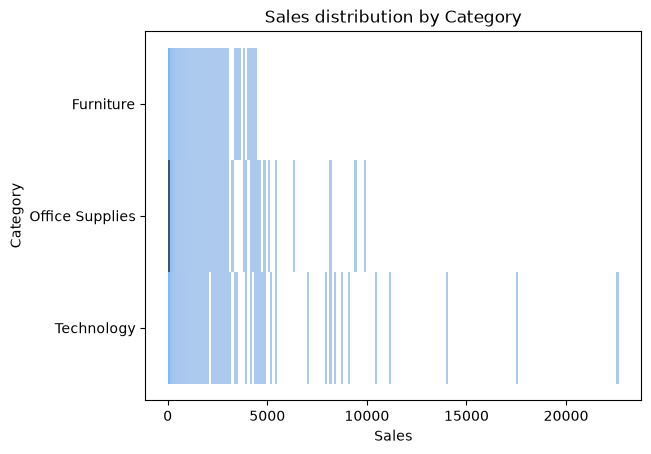

In [165]:

plt.Figure(figsize=(12,6))
sns.histplot(x=df['Sales'],y=df['Category'])
plt.title("Sales distribution by Category")

Text(0.5, 1.0, 'Sales distribution by Region')

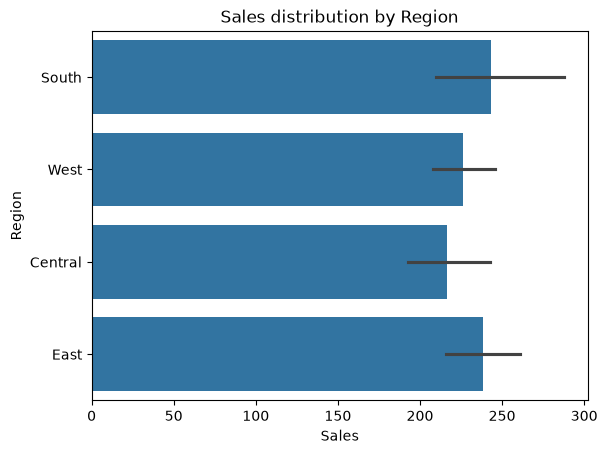

In [166]:

plt.Figure(figsize=(12,6))
sns.barplot(x=df['Sales'],y=df['Region'])
plt.title("Sales distribution by Region")

Text(0.5, 1.0, 'Sales distribution by Sub-Category')

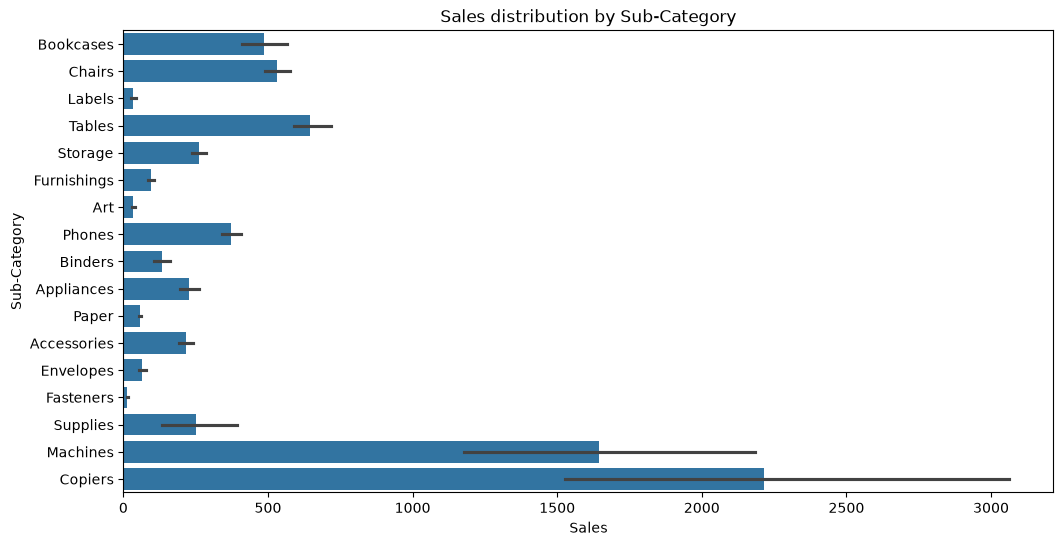

In [167]:

plt.figure(figsize=(12,6))
sns.barplot(x=df['Sales'],y=df['Sub-Category'])
plt.title("Sales distribution by Sub-Category")

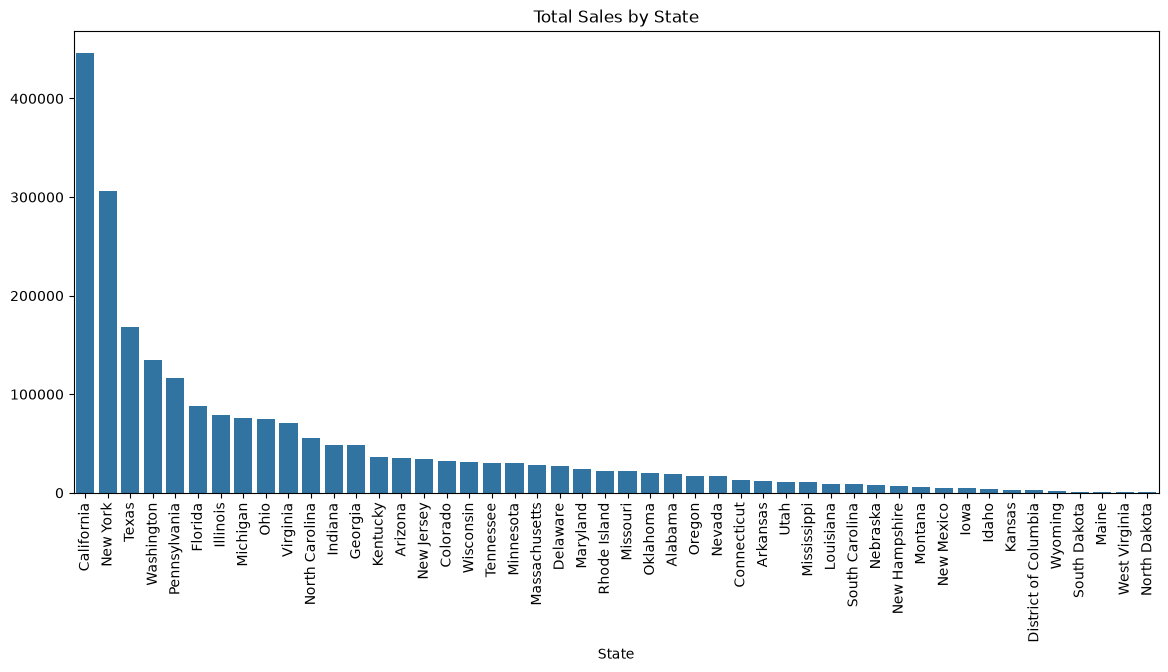

In [168]:
plt.figure(figsize=(14,6))

sales_state = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

sns.barplot(x=sales_state.index, y=sales_state.values)

plt.xticks(rotation=90)
plt.title("Total Sales by State")
plt.show()

Text(0.5, 1.0, 'Sales distribution by Country')

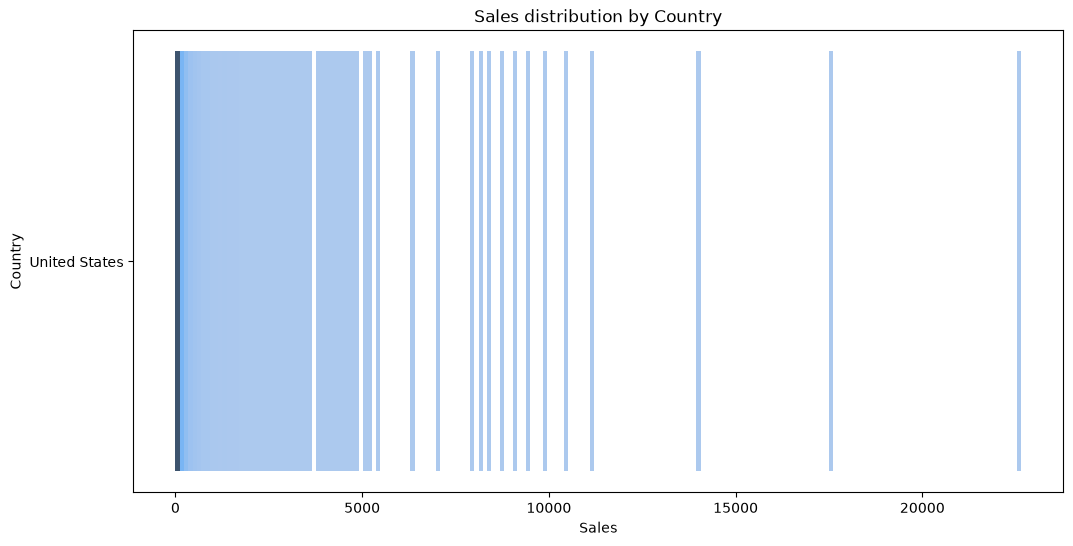

In [169]:
plt.figure(figsize=(12,6))
sns.histplot(x=df['Sales'],y=df['Country'],kde=True)
plt.title("Sales distribution by Country")

Text(0.5, 1.0, 'Sales Distribution by Segment')

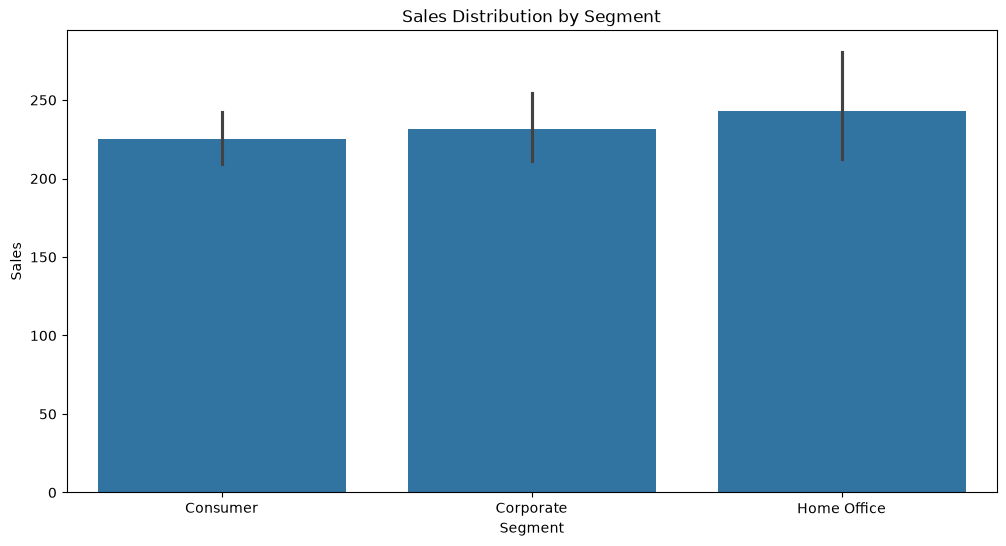

In [170]:
plt.figure(figsize=(12,6))
sns.barplot(data=df,y='Sales',x='Segment')
plt.title("Sales Distribution by Segment")

In [171]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

Text(0.5, 1.0, 'Sales Distribution by Month')

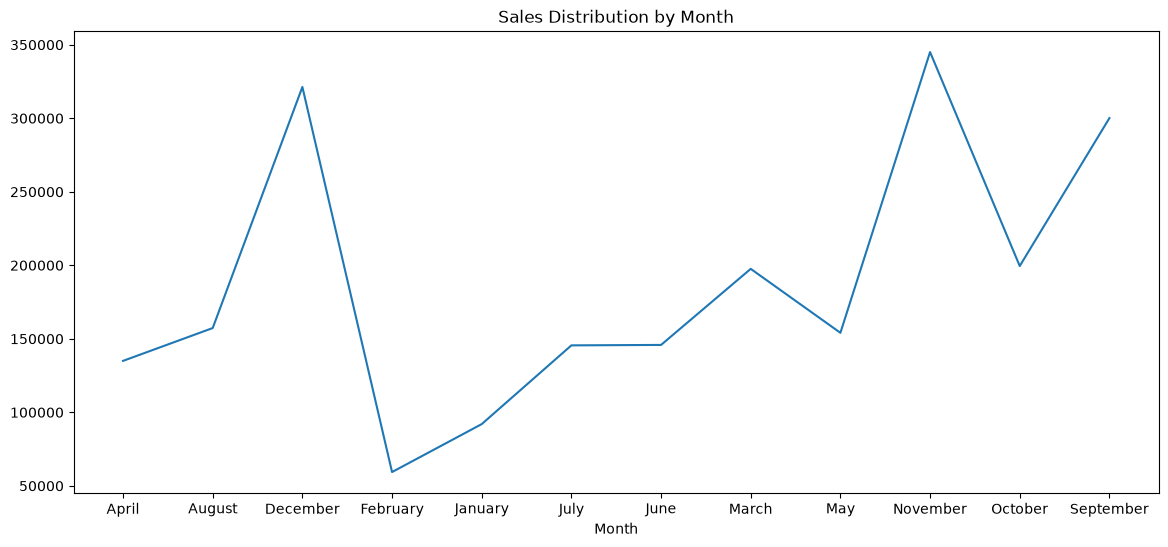

In [172]:
plt.figure(figsize=(14,6))
df["Month"] = df["Order Date"].dt.month_name()

monthly = df.groupby("Month")["Sales"].sum()

sns.lineplot(x=monthly.index, y=monthly.values)
plt.title("Sales Distribution by Month")

Text(0.5, 1.0, 'Sales Distribution by Month')

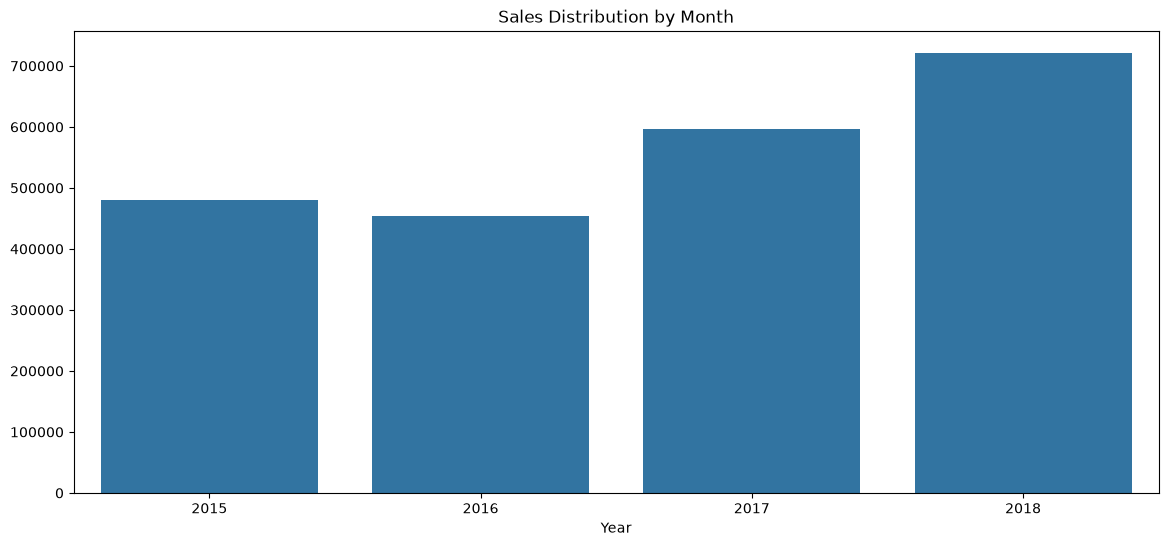

In [173]:
plt.figure(figsize=(14,6))
df["Year"] = df["Order Date"].dt.year
yearly= df.groupby("Year")["Sales"].sum()

sns.barplot(x=yearly.index, y=yearly.values)
plt.title("Sales Distribution by Month")

<Axes: ylabel='Product Name'>

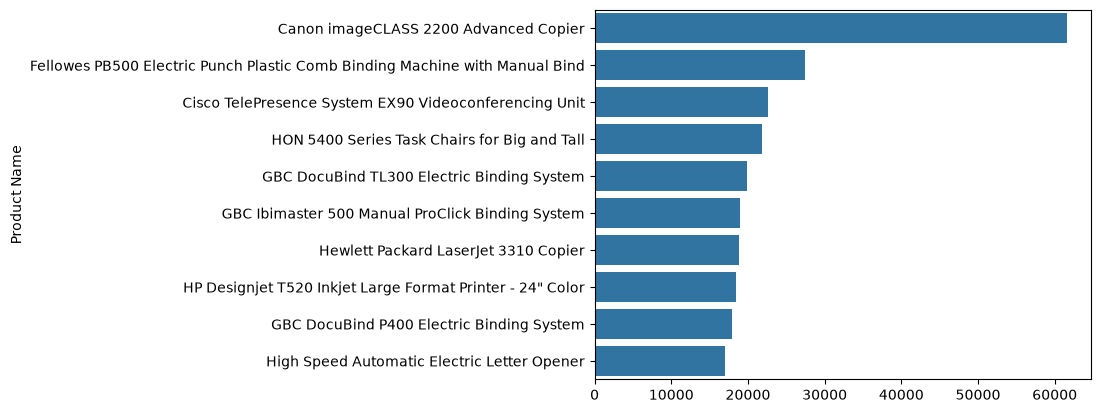

In [174]:
product_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=product_sales.values, y=product_sales.index)

<Axes: xlabel='Category', ylabel='count'>

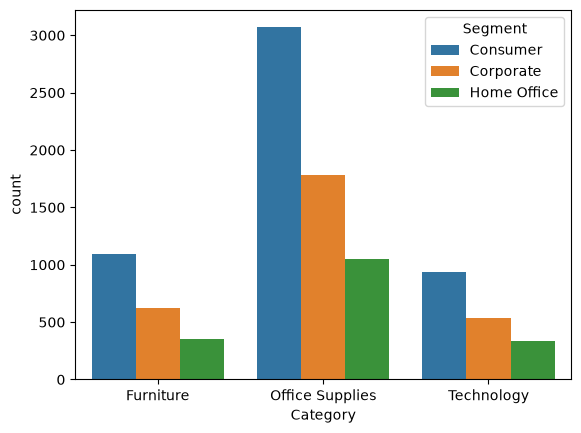

In [175]:
sns.countplot(data=df, x="Category", hue="Segment")

<Axes: xlabel='Region', ylabel='count'>

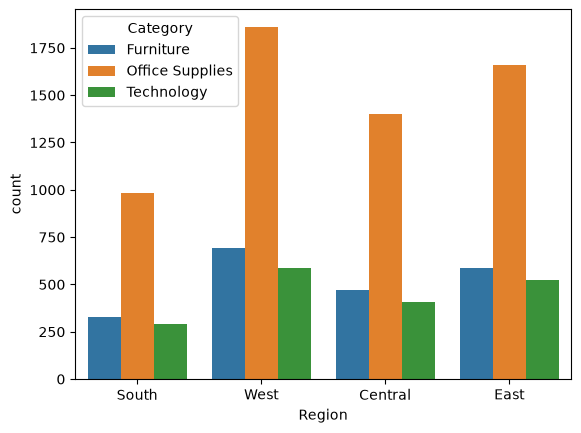

In [176]:
sns.countplot(data=df, x="Region", hue="Category")

<Axes: xlabel='Ship Mode', ylabel='count'>

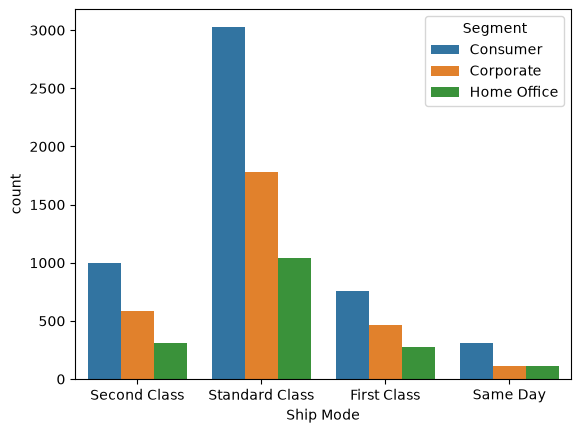

In [177]:
sns.countplot(data=df, x="Ship Mode", hue="Segment")

<Axes: ylabel='City'>

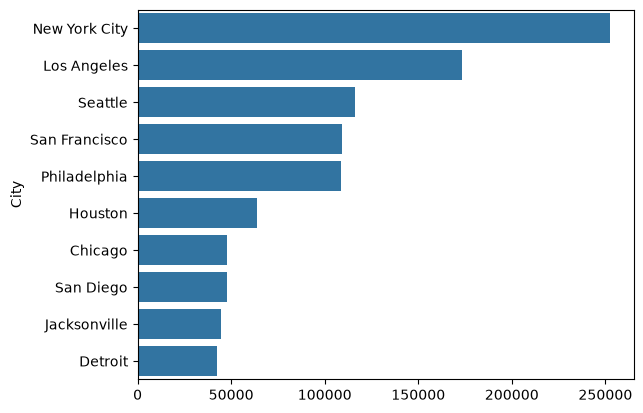

In [178]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

sns.barplot(x=city_sales.values, y=city_sales.index)

<Axes: xlabel='Ship Mode', ylabel='Sales'>

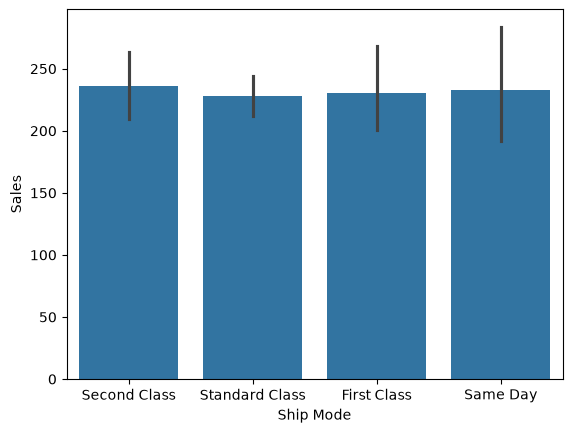

In [179]:
sns.barplot(data=df, x="Ship Mode", y="Sales")

In [180]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month,Year
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,November,2017
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,November,2017
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,June,2017
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,October,2016
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,October,2016


In [181]:
# Drop rows where target is missing
df = df.dropna(subset=["Sales"]).copy()

# Parse dates
for col in ["Order Date", "Ship Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Create useful date features
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Day"] = df["Order Date"].dt.day
df["Order_DayOfWeek"] = df["Order Date"].dt.dayofweek
df["Order_Quarter"] = df["Order Date"].dt.quarter
df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

# Convert string month to 0/1 dummy columns
if "Month" in df.columns:
    month_dummies = pd.get_dummies(df["Month"], prefix="Month", dtype=int)
    df = pd.concat([df.drop(columns=["Month"]), month_dummies], axis=1)

# Drop ID-like and date columns
drop_cols = [
    "Row ID", "Order ID", "Customer ID", "Customer Name",
    "Product ID", "Product Name", "Postal Code",
    "Order Date", "Ship Date"
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# Fill missing values
for col in df.columns:
    if col == "Sales":
        continue
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(0)

# One-hot encode other categorical columns
cat_cols = [
    "Ship Mode", "Segment", "Region", "Category",
    "Sub-Category", "Country", "State", "City"
]
cat_cols = [c for c in cat_cols if c in df.columns]

X = pd.get_dummies(df.drop(columns=["Sales"]), columns=cat_cols, dtype=int)
y = df["Sales"].astype(float)

X.head()

,Year,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Order_Quarter,Shipping_Days,Month_April,Month_August,Month_December,...,City_Wilmington,City_Wilson,City_Woodbury,City_Woodland,City_Woodstock,City_Woonsocket,City_Yonkers,City_York,City_Yucaipa,City_Yuma
0,2017,2017,11,8,2,4,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2017,2017,11,8,2,4,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2017,2017,6,12,0,2,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2016,2016,10,11,1,4,7,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2016,2016,10,11,1,4,7,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [182]:
'''from scipy.stats import pearsonr


selected_features = [ 'Sales', 
       'Category_Office Supplies', 'Category_Technology',
       'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders',
       'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers',
       'Sub-Category_Envelopes', 'Sub-Category_Fasteners',
       'Sub-Category_Furnishings', 'Sub-Category_Labels',
       'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones',
       'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables',
       'Region_East', 'Region_South', 'Region_West', 'Segment_Corporate',
       'Segment_Home Office', 'Ship Mode_Same Day', 'Ship Mode_Second Class',
       'Ship Mode_Standard Class', 'Order_Year', 'Order_Month', 'Order_Day',
       'Order_DayOfWeek', 'Shipping_Days']
coorelations = {
feature:pearsonr(df[feature] , df['Sales'])[0]
    for feature in selected_features
}
coorelation_df= pd.DataFrame(list(coorelations.items()),columns = ['feature','pearson coorelation'])
coorelation_df.sort_values(by='pearson coorelation',ascending=False)'''

"from scipy.stats import pearsonr\n\n\nselected_features = [ 'Sales', \n       'Category_Office Supplies', 'Category_Technology',\n       'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders',\n       'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers',\n       'Sub-Category_Envelopes', 'Sub-Category_Fasteners',\n       'Sub-Category_Furnishings', 'Sub-Category_Labels',\n       'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones',\n       'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables',\n       'Region_East', 'Region_South', 'Region_West', 'Segment_Corporate',\n       'Segment_Home Office', 'Ship Mode_Same Day', 'Ship Mode_Second Class',\n       'Ship Mode_Standard Class', 'Order_Year', 'Order_Month', 'Order_Day',\n       'Order_DayOfWeek', 'Shipping_Days']\ncoorelations = {\nfeature:pearsonr(df[feature] , df['Sales'])[0]\n    for feature in selected_features\n}\ncoorelation_df= pd.DataFrame(list(coorelations.it

In [183]:
df.info()

<class 'pandas.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Ship Mode        9789 non-null   str    
 1   Segment          9789 non-null   str    
 2   Country          9789 non-null   str    
 3   City             9789 non-null   str    
 4   State            9789 non-null   str    
 5   Region           9789 non-null   str    
 6   Category         9789 non-null   str    
 7   Sub-Category     9789 non-null   str    
 8   Sales            9789 non-null   float64
 9   Year             9789 non-null   int32  
 10  Order_Year       9789 non-null   int32  
 11  Order_Month      9789 non-null   int32  
 12  Order_Day        9789 non-null   int32  
 13  Order_DayOfWeek  9789 non-null   int32  
 14  Order_Quarter    9789 non-null   int32  
 15  Shipping_Days    9789 non-null   int64  
 16  Month_April      9789 non-null   int64  
 17  Month_August     9789 non-null

In [184]:
categorical_cols = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode",
    "Country",
    "State",
    "City"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [185]:
bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [201]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [202]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = [
   'Year',	'Order_Year',	'Order_Month',	'Order_Day',	'Order_DayOfWeek',	'Order_Quarter',	'Shipping_Days'
]

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [204]:
print(X_train.dtypes[X_train.dtypes == "datetime64[ns]"])

Series([], dtype: object)


In [205]:
df.head()

,Sales,Year,Order_Year,Order_Month,Order_Day,Order_DayOfWeek,Order_Quarter,Shipping_Days,Month_April,Month_August,...,City_Wilmington,City_Wilson,City_Woodbury,City_Woodland,City_Woodstock,City_Woonsocket,City_Yonkers,City_York,City_Yucaipa,City_Yuma
0,261.9600,2017,2017,11,8,2,4,3,0,0,...,0,0,0,0,0,0,0,0,0,0
1,731.9400,2017,2017,11,8,2,4,3,0,0,...,0,0,0,0,0,0,0,0,0,0
2,14.6200,2017,2017,6,12,0,2,4,0,0,...,0,0,0,0,0,0,0,0,0,0
3,957.5775,2016,2016,10,11,1,4,7,0,0,...,0,0,0,0,0,0,0,0,0,0
4,22.3680,2016,2016,10,11,1,4,7,0,0,...,0,0,0,0,0,0,0,0,0,0


In [206]:
df.dtypes

Sales              float64
Year                 int32
Order_Year           int32
Order_Month          int32
Order_Day            int32
                    ...   
City_Woonsocket      int64
City_Yonkers         int64
City_York            int64
City_Yucaipa         int64
City_Yuma            int64
Length: 621, dtype: object

In [207]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='str')


In [209]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](620,)","[ -3.53, -3.53, 1.68,..., 185.98, 172.37,-213.82]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](620,)","['Year','Order_Year','Order_Month',...,'City_York','City_Yucaipa', 'City_Yuma']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.457e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,620
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(583)


In [210]:
y_predi = model.predict(X_test)
y_predi

array([ 95.65088781, 104.79941188, -17.51177756, ..., 420.29237026,
       197.77921654, 109.92428587], shape=(1958,))

In [211]:
y_test

8962     273.960
7138      62.880
4709      11.680
6204       7.712
6901    2399.960
          ...   
1888     121.792
6312     579.510
6226     291.168
2881      27.930
3791       4.419
Name: Sales, Length: 1958, dtype: float64

In [212]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
                

In [217]:
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.1908350232607382
MAE: 246.80522950838633
RMSE: 629.1183386159918


In [218]:
'''from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=30,
    random_state=42
)

model_rf.fit(X_train, y_train)'''
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [219]:
ry_predi = model_rf.predict(X_test)
ry_predi

array([303.60491666, 104.73973838,  27.59518987, ..., 362.99085343,
        33.52884367,  94.77550936], shape=(1958,))

In [220]:
y_test

8962     273.960
7138      62.880
4709      11.680
6204       7.712
6901    2399.960
          ...   
1888     121.792
6312     579.510
6226     291.168
2881      27.930
3791       4.419
Name: Sales, Length: 1958, dtype: float64

In [221]:
rfy_pred = model_rf.predict(X_test)

print("R2:", r2_score(y_test, rfy_pred))
print("MAE:", mean_absolute_error(y_test, rfy_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rfy_pred)))

R2: 0.17575801888595854
MAE: 228.8075418297375
RMSE: 634.9524040300333


In [222]:
print(type(model))
print(type(model_rf))

<class 'sklearn.linear_model._base.LinearRegression'>
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [223]:
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [224]:
model_gb = GradientBoostingRegressor(n_estimators = 100,random_state = 42,learning_rate = 0.1)


In [225]:
model_gb.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [226]:
gby_predi = model_gb.predict(X_test)
gby_predi

array([121.07902836, 100.03917021,  65.58980456, ..., 490.56215951,
       150.74378162, 100.03917021], shape=(1958,))

In [227]:
y_test

8962     273.960
7138      62.880
4709      11.680
6204       7.712
6901    2399.960
          ...   
1888     121.792
6312     579.510
6226     291.168
2881      27.930
3791       4.419
Name: Sales, Length: 1958, dtype: float64

In [228]:
gby_pred = model_gb.predict(X_test)

print("R2:", r2_score(y_test, gby_pred))
print("MAE:", mean_absolute_error(y_test, gby_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gby_pred)))

R2: 0.19196836149469698
MAE: 225.1270660098918
RMSE: 628.6776042012331


In [229]:
xg_model= XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    use_label_encoder = True,
    eval_metric = 'mlogloss',
    random_state = 42
)

In [230]:
xg_model.fit(X_train,y_train)

d:\New folder\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:56:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mlogloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [231]:
y_pred = xg_model.predict(X_test)
y_pred

array([123.86593, 104.41476,  66.02681, ..., 493.7764 , 169.88644,
       104.41476], shape=(1958,), dtype=float32)

In [232]:
y_test

8962     273.960
7138      62.880
4709      11.680
6204       7.712
6901    2399.960
          ...   
1888     121.792
6312     579.510
6226     291.168
2881      27.930
3791       4.419
Name: Sales, Length: 1958, dtype: float64

In [233]:
xgy_pred = xg_model.predict(X_test)

print("R2:", r2_score(y_test, gby_pred))
print("MAE:", mean_absolute_error(y_test, xgy_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgy_pred)))

R2: 0.19196836149469698
MAE: 226.037875283056
RMSE: 626.7917710252264


In [239]:
lr_pred = model.predict(X_test)

rf_pred = model_rf.predict(X_test)

gb_pred = model_gb.predict(X_test)

xgb_pred = xg_model.predict(X_test)

In [240]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
        r2_score(y_test, xgb_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ]
})

print(results)

               Model        R2         MAE        RMSE
0  Linear Regression  0.190835  246.805230  629.118339
1      Random Forest  0.175758  228.807542  634.952404
2  Gradient Boosting  0.191968  225.127066  628.677604
3            XGBoost  0.196809  226.037875  626.791771


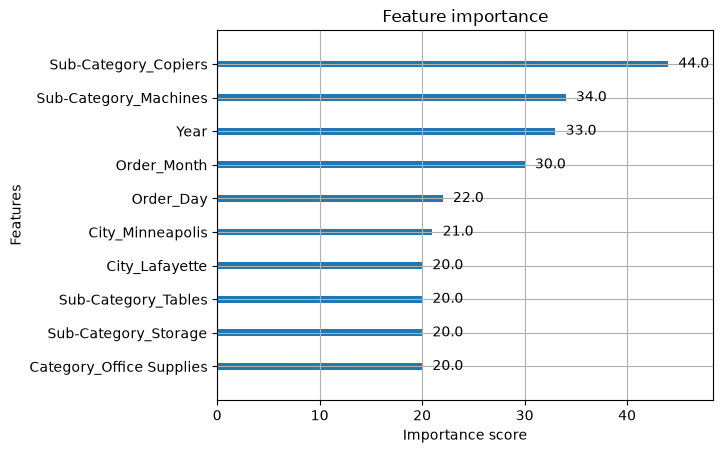

In [241]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xg_model, max_num_features=10)
plt.show()

In [242]:
import joblib

joblib.dump(xg_model, "sales_prediction_xgboost.pkl")

['sales_prediction_xgboost.pkl']